In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df=pd.read_csv('data/dataset.csv')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
df.head(5)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

In [17]:
nulos=pd.DataFrame({
    'nulos':df.isna().sum(),
    '%':(df.isna().mean()*100).round(1),
})
nulos[nulos['nulos']>0]

,nulos,%
artists,1,0.0
album_name,1,0.0
track_name,1,0.0


In [20]:
df['track_genre'].value_counts()

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
               ... 
techno         1000
trance         1000
trip-hop       1000
turkish        1000
world-music    1000
Name: count, Length: 114, dtype: int64

In [73]:
mediana_speech=df.groupby('track_genre')['danceability'].median().sort_values()

In [63]:
mediana_speech.head(1)

track_genre
honky-tonk    0.03215
Name: speechiness, dtype: float64

In [64]:
mediana_speech.tail(1)

track_genre
comedy    0.917
Name: speechiness, dtype: float64

In [74]:
x1=mediana_dance.quantile(0.2)
x2=mediana_dance.quantile(0.8)
dance_mais=mediana_dance[mediana_dance>=x2]
dance_menos=mediana_dance[mediana_dance<=x1]

In [76]:
print(dance_mais)

track_genre
house             0.6740
chill             0.6740
salsa             0.6840
j-dance           0.6845
french            0.6860
afrobeat          0.6910
disco             0.6930
dance             0.6950
study             0.6955
techno            0.6990
funk              0.6995
sad               0.7055
deep-house        0.7170
children          0.7280
latin             0.7400
minimal-techno    0.7425
detroit-techno    0.7460
dancehall         0.7490
hip-hop           0.7530
reggae            0.7560
reggaeton         0.7620
latino            0.7620
chicago-house     0.7790
kids              0.7940
Name: danceability, dtype: float64


In [75]:
print(dance_menos)

track_genre
sleep          0.1610
grindcore      0.2650
iranian        0.2810
black-metal    0.2820
opera          0.2900
new-age        0.3375
ambient        0.3640
death-metal    0.3715
classical      0.3770
romance        0.4185
world-music    0.4235
metalcore      0.4390
heavy-metal    0.4450
piano          0.4470
disney         0.4575
grunge         0.4675
metal          0.4720
goth           0.4760
show-tunes     0.4785
gospel         0.4790
power-pop      0.4790
hard-rock      0.4820
garage         0.4945
Name: danceability, dtype: float64


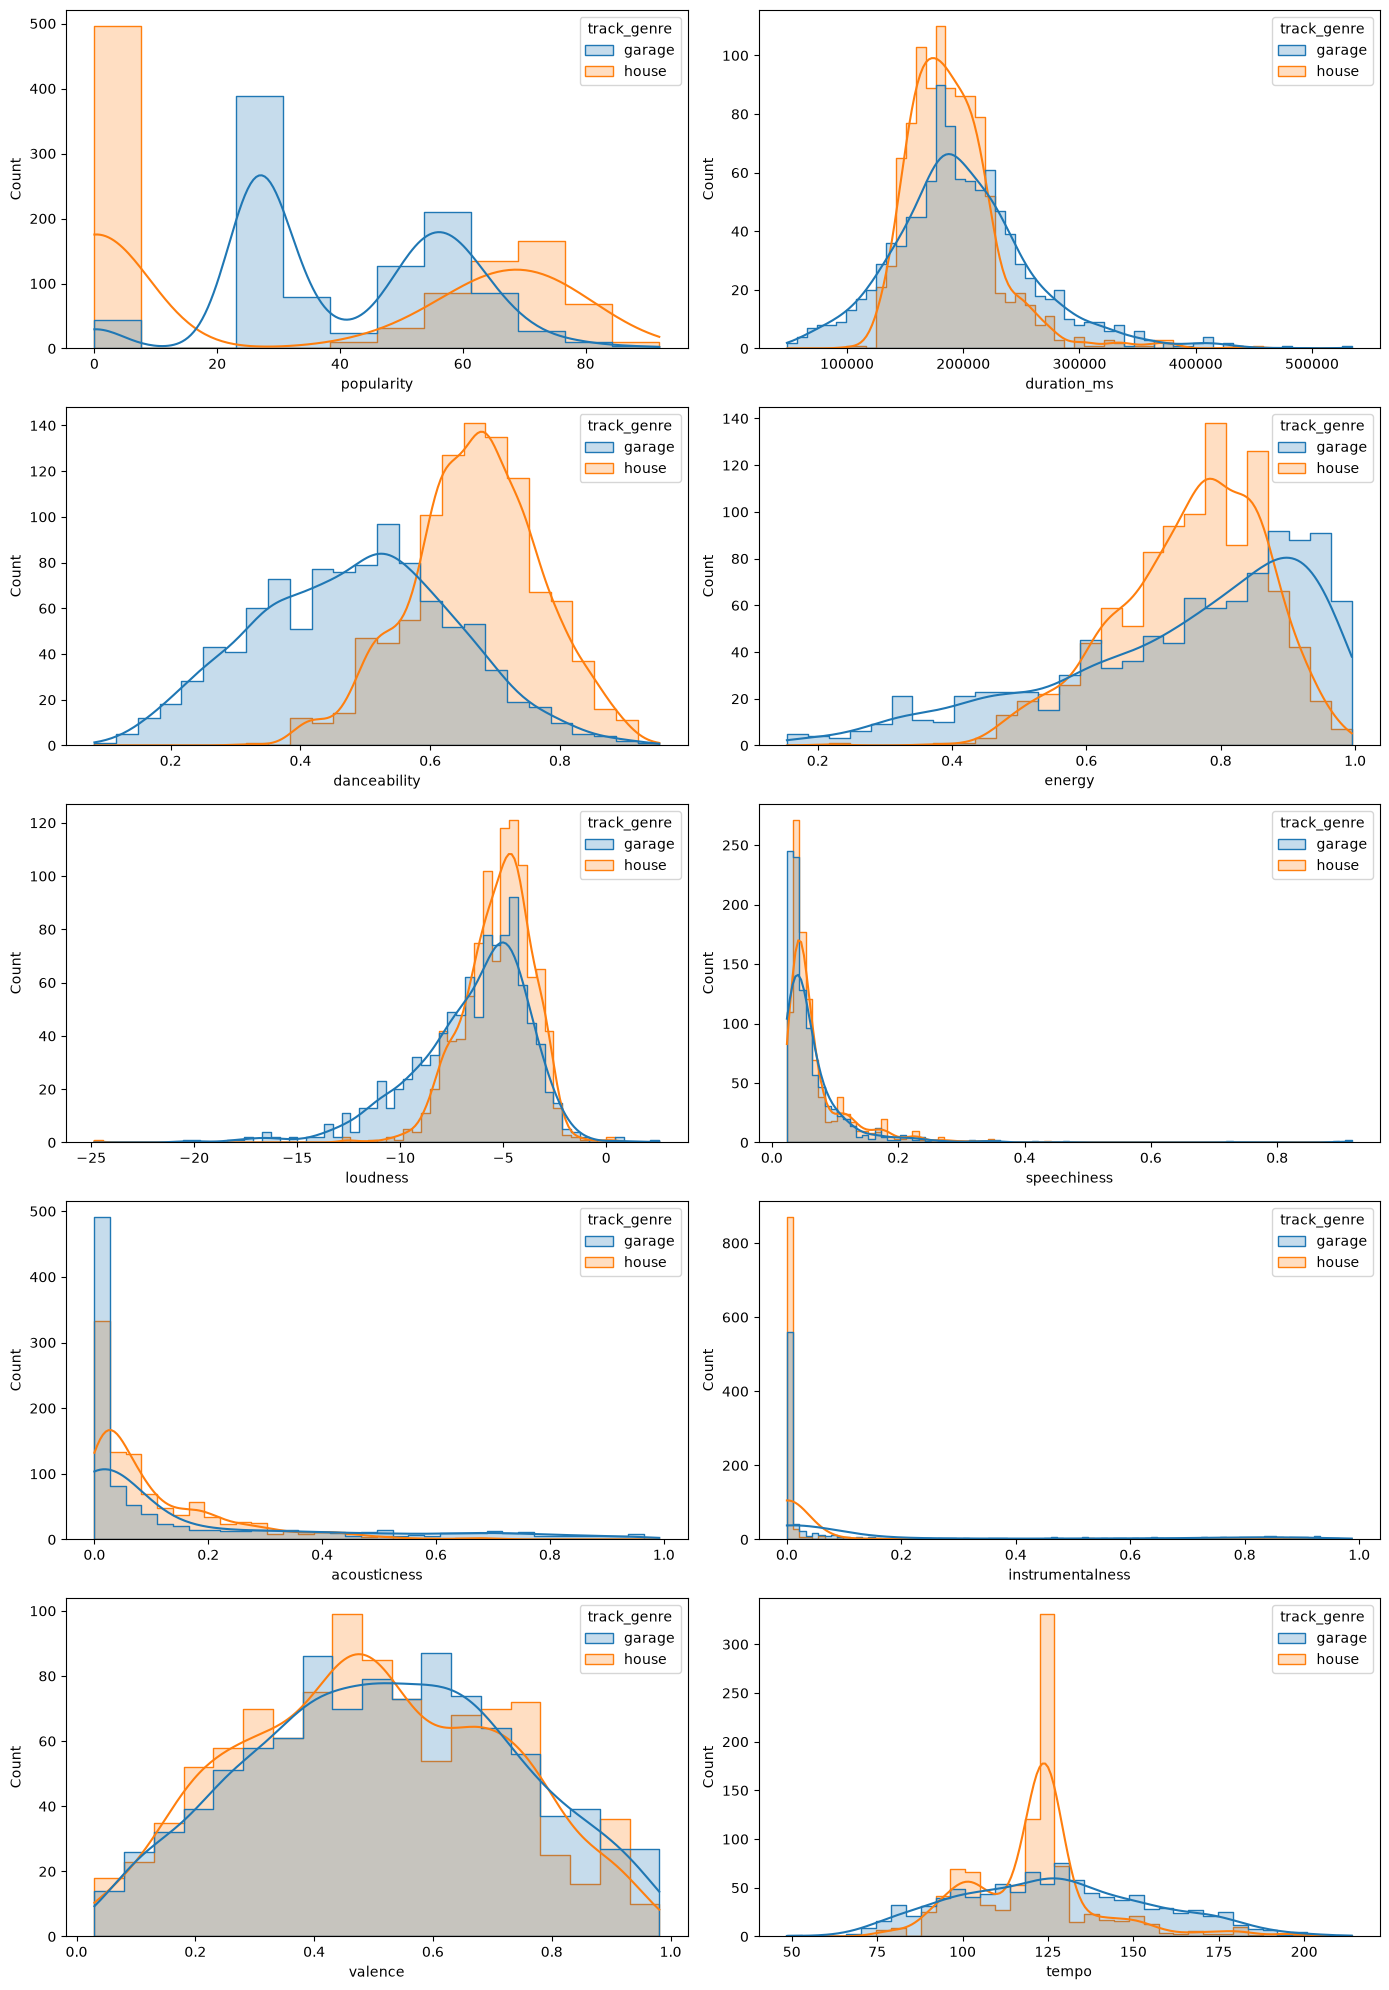

In [77]:
variaveis=['popularity','duration_ms','danceability','energy','loudness',
'speechiness','acousticness','instrumentalness','valence','tempo']
df_filtro=df[df['track_genre'].isin(['house','garage'])]
fig , axes = plt.subplots(5,2,figsize=(14,20))
axes=axes.flatten()
for i, var in enumerate(variaveis):
    sns.histplot(data=df_filtro,x=var,hue='track_genre',kde=True,ax=axes[i],element='step')
plt.tight_layout()
plt.show()

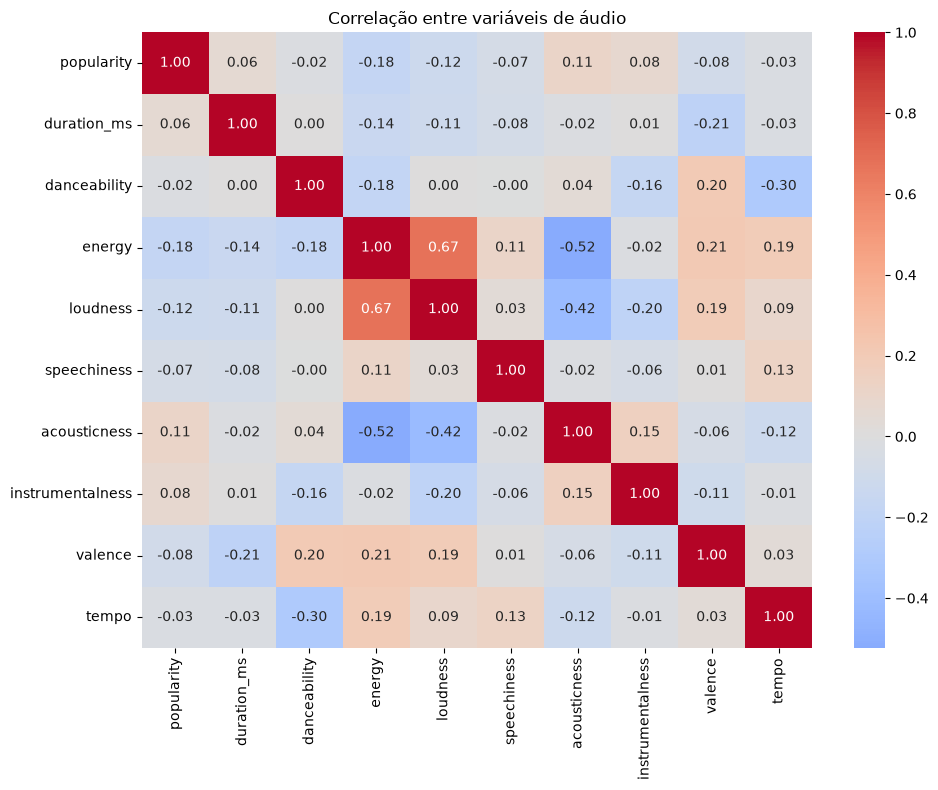

In [78]:
df_comp=df[df['track_genre'].isin(['house','garage'])]
corr=df_comp[variaveis].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f',cmap='coolwarm',center=0)
plt.title('Correlação entre variáveis de áudio')
plt.tight_layout()
plt.show()